# Tăng cường dữ liệu ảnh giao thông bằng chuyển phong cách thời tiết

### Bài tập cuối khoá — môn Deep Learning Ứng dụng

**Nhóm 6** — Hoàng Minh Đức · Trần Quý Đạt · Hoàng Trung Kiên · Vũ Thuỳ Linh

Mã nguồn đầy đủ: <https://github.com/QuyDatSadBoy/StyleTranfer_Viettel_Course_DeepLearning>

---

## Bài toán

> Cho **một ảnh giao thông chụp trong điều kiện bình thường** và **một ảnh tham chiếu thời tiết**
> (mưa / tuyết / sương mù / mù khô / bão cát), sinh ra ảnh giao thông đó dưới điều kiện thời tiết
> mong muốn, để **tăng cường dữ liệu huấn luyện** cho các mô hình thị giác máy tính trên đường phố.

**Động lực.** Mô hình phát hiện vật thể suy giảm mạnh khi thời tiết xấu, vì dữ liệu huấn luyện
lệch nặng về ảnh trời quang (trong BDD100K, ảnh mưa/tuyết ban ngày chỉ chiếm ~8%). Thu thập thêm
ảnh thời tiết xấu vừa phải chờ đúng thời tiết, vừa phải gán nhãn lại từ đầu.

**Ý tưởng.** Sinh ảnh thời tiết xấu từ ảnh **đã có nhãn**. Toàn bộ pipeline chỉ thay đổi *giá trị
màu tại từng điểm ảnh*, không làm dịch chuyển vật thể — nên **nhãn bounding box cũ được dùng lại
100%**, chi phí gán nhãn cho dữ liệu mới bằng **0**.

## Kiến trúc — 3 khối nối tiếp

```
   ẢNH GIAO THÔNG (trời quang)          ẢNH THAM CHIẾU (mưa/tuyết/sương)
              │                                      │
              └──────────► VGG-19 (đóng băng) ◄───────┘
                                 │
                      ┌──────────▼──────────┐
                      │ ① AdaIN             │   σ(s)·(c−μ(c))/σ(c) + μ(s)
                      └──────────┬──────────┘
                            Decoder (phần DUY NHẤT được học, 3,51M tham số)
                      ┌──────────▼──────────┐
                      │ ② Guided Filter     │   q = a·I + b   (I = ảnh gốc)
                      └──────────┬──────────┘
                      ┌──────────▼──────────┐
                      │ ③ Phủ hạt (vật lý)  │   vệt mưa / bông tuyết / bụi cát
                      └──────────┬──────────┘
                                 ▼
                 ẢNH THỜI TIẾT XẤU + NHÃN CŨ DÙNG LẠI 100%
```

| Khối | Có học không? | Vai trò |
|---|---|---|
| ① AdaIN | Không có tham số. Chỉ **Decoder** phía sau được học | Đổi tông màu, độ sáng, độ mù toàn cục |
| ② Guided Filter | Không | Trả lại biên sắc nét của ảnh gốc → ảnh trông như ảnh chụp thật |
| ③ Phủ hạt | Không | Thêm chi tiết cục bộ mà AdaIN không tạo được |

## 0. Chuẩn bị

In [1]:
import json, random, sys, time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent          # phòng khi notebook nằm trong thư mục con
sys.path.insert(0, str(ROOT))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42); np.random.seed(42); random.seed(42)

print("PyTorch :", torch.__version__)
print("Thiết bị:", DEVICE, f"({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else "")
print("Thư mục dự án:", ROOT)

PyTorch : 2.11.0+cu128
Thiết bị: cuda (NVIDIA GeForce RTX 5060 Ti)
Thư mục dự án: /home/phongndh/Documents/DeepLearning_Project


In [2]:
def show(images, titles=None, cols=None, figsize_w=16, title=None):
    """Hiển thị một dãy ảnh RGB uint8 cho gọn."""
    n = len(images); cols = cols or n; rows = int(np.ceil(n / cols))
    h_ratio = images[0].shape[0] / images[0].shape[1]
    fig, axes = plt.subplots(rows, cols,
                             figsize=(figsize_w, figsize_w / cols * h_ratio * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, im, i in zip(axes, images, range(n)):
        ax.imshow(im); ax.axis("off")
        if titles: ax.set_title(titles[i], fontsize=10)
    for ax in axes[n:]: ax.axis("off")
    if title: fig.suptitle(title, fontsize=13, y=1.0)
    plt.tight_layout(); plt.show()

def load_img(path, max_side=640):
    im = Image.open(path).convert("RGB")
    s = max_side / max(im.size)
    if s < 1:
        im = im.resize((int(im.size[0] * s), int(im.size[1] * s)), Image.LANCZOS)
    return np.asarray(im)

to_t = lambda a: torch.from_numpy(a.astype(np.float32) / 255).permute(2, 0, 1)[None].to(DEVICE)
to_np = lambda t: (t[0].detach().clamp(0, 1).cpu().permute(1, 2, 0).numpy() * 255).round().astype(np.uint8)
print("Đã định nghĩa hàm tiện ích.")

Đã định nghĩa hàm tiện ích.


---
## 1. Dữ liệu

Hai bộ dữ liệu công khai, tải tự động bằng `python scripts/01_download_data.py`
(không cần đăng ký tài khoản):

| Bộ dữ liệu | Vai trò | Giấy phép |
|---|---|---|
| **BDD100K** (subset 10k, mirror HuggingFace `dgural/bdd100k`) | Ảnh **nội dung** (trời quang, ban ngày) + ảnh mưa/tuyết thật làm **tập test** | BSD-3-Clause |
| **DAWN** (Mendeley, DOI 10.17632/766ygrbt8y.3) | Ảnh **tham chiếu thời tiết** | Chỉ nghiên cứu |

BDD100K được chọn vì mỗi ảnh có sẵn **ba** loại nhãn cần thiết cùng lúc: nhãn `weather`
(lọc ảnh trời quang / ảnh thời tiết xấu), nhãn `timeofday` (loại ảnh ban đêm), và
**bounding box** 10 lớp (dùng cho thí nghiệm kiểm chứng ở mục 9).

> **Chống rò rỉ dữ liệu:** tập ảnh mưa/tuyết thật được chia đôi — 300 ảnh đầu vào kho ảnh tham
> chiếu, phần còn lại **chỉ** dùng làm tập test, không xuất hiện ở bất kỳ khâu nào khác.

In [3]:
splits = json.load(open(ROOT / "data/processed/splits.json"))

print(f"Ảnh nội dung (trời quang) : {len(splits['content_train'])} train / {len(splits['content_val'])} val")
print(f"Ảnh tham chiếu thời tiết  : " +
      ", ".join(f"{k}={len(v)}" for k, v in sorted(splits["style_pool"].items())) +
      f"  (tổng {sum(len(v) for v in splits['style_pool'].values())})")
print(f"Tập test (mưa/tuyết THẬT) : {len(splits['det_test_adverse'])} ảnh")
print(f"Lớp vật thể ({len(splits['classes'])}): {', '.join(splits['classes'])}")

Ảnh nội dung (trời quang) : 2160 train / 240 val
Ảnh tham chiếu thời tiết  : fog=186, haze=114, rain=343, sand=323, snow=361  (tổng 1327)
Tập test (mưa/tuyết THẬT) : 500 ảnh
Lớp vật thể (10): pedestrian, rider, car, truck, bus, train, motorcycle, bicycle, traffic light, traffic sign


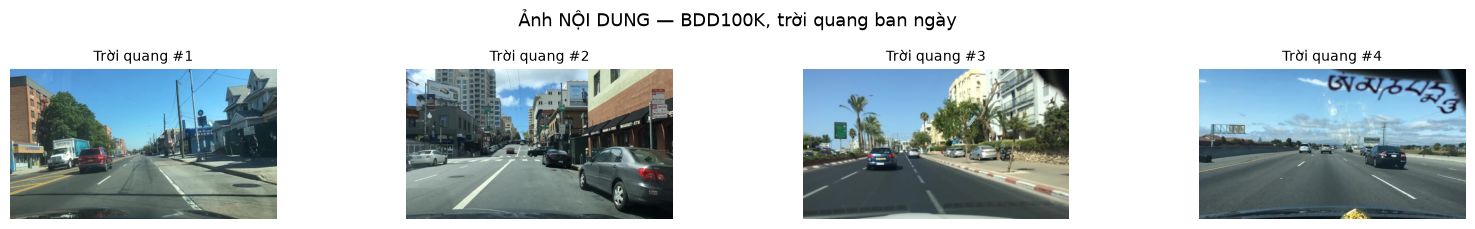

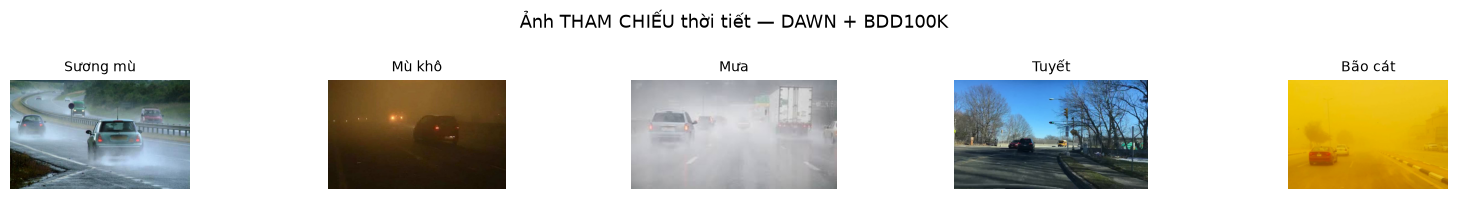

In [4]:
rng = random.Random(0)
show([load_img(ROOT / p, 420) for p in rng.sample(splits["content_val"], 4)],
     [f"Trời quang #{i+1}" for i in range(4)], title="Ảnh NỘI DUNG — BDD100K, trời quang ban ngày")

show([load_img(ROOT / rng.choice(splits["style_pool"][k]), 420)
      for k in ["fog", "haze", "rain", "snow", "sand"]],
     ["Sương mù", "Mù khô", "Mưa", "Tuyết", "Bão cát"],
     title="Ảnh THAM CHIẾU thời tiết — DAWN + BDD100K")

---
## 2. Khối ① — AdaIN (Adaptive Instance Normalization)

Huang & Belongie, *Arbitrary Style Transfer in Real-time with Adaptive Instance Normalization*,
ICCV 2017. Toàn bộ phương pháp gói gọn trong **một công thức**:

$$\mathrm{AdaIN}(c,\,s) \;=\; \sigma(s)\cdot\frac{c-\mu(c)}{\sigma(c)} \;+\; \mu(s)$$

trong đó $c$, $s$ là đặc trưng VGG của ảnh nội dung và ảnh tham chiếu; $\mu$, $\sigma$ là trung
bình và độ lệch chuẩn tính **theo từng kênh, từng ảnh**.

**Diễn giải.**
- Phép chia $\dfrac{c-\mu(c)}{\sigma(c)}$ xoá phong cách gốc (tông trời quang) nhưng **giữ nguyên
  cấu trúc không gian** — vị trí xe, làn đường, biển báo nằm ở đâu vẫn ở đó.
- Phép nhân $\sigma(s)$ và cộng $\mu(s)$ "nhuộm" đặc trưng bằng thống kê của ảnh thời tiết.

Vì chỉ thống kê **theo kênh** bị thay đổi, bản đồ đặc trưng không hề bị dịch chuyển — đây chính
là lý do nhãn bounding box vẫn dùng lại được.

**AdaIN không có tham số học nào.** Chỉ Decoder phía sau được huấn luyện.

In [5]:
EPS = 1e-5

def calc_mean_std(feat):
    """Mean/std theo từng ảnh, từng kênh: (B,C,H,W) -> (B,C,1,1).
    Luôn tính ở float32 vì phương sai ở bf16/fp16 sai số lớn."""
    b, c = feat.shape[:2]
    f = feat.float().reshape(b, c, -1)
    mean = f.mean(dim=2).reshape(b, c, 1, 1)
    std = (f.var(dim=2) + EPS).sqrt().reshape(b, c, 1, 1)
    return mean.to(feat.dtype), std.to(feat.dtype)


def adain(content_feat, style_feat, std_floor: float = 0.0):
    """AdaIN(c,s) = sigma(s) * (c - mu(c)) / sigma(c) + mu(s)

    std_floor — PHẦN BỔ SUNG so với bài báo gốc. Ảnh sương mù dày gần như đồng
    màu nên sigma(s) rất nhỏ; AdaIN thuần sẽ nén tương phản ảnh nội dung về gần 0,
    ảnh ra trắng xoá, không còn nhìn thấy xe/người — vô dụng (thậm chí có hại) khi
    dùng làm dữ liệu huấn luyện detection. Ta chặn tỉ lệ nén không thấp hơn
    std_floor. std_floor = 0 chính là công thức gốc.
    """
    c_mean, c_std = calc_mean_std(content_feat)
    s_mean, s_std = calc_mean_std(style_feat)
    if std_floor > 0:
        s_std = torch.maximum(s_std, std_floor * c_std)
    return (content_feat - c_mean) / c_std * s_std + s_mean


# kiểm chứng: sau AdaIN, mean/std của đặc trưng phải KHỚP với ảnh phong cách
c = torch.randn(1, 8, 16, 16, device=DEVICE) * 2.0 + 5.0
s = torch.randn(1, 8, 16, 16, device=DEVICE) * 0.5 - 1.0
t = adain(c, s)
print("std đặc trưng nội dung  :", calc_mean_std(c)[1].mean().item().__round__(4))
print("std đặc trưng phong cách:", calc_mean_std(s)[1].mean().item().__round__(4))
print("std sau khi AdaIN       :", calc_mean_std(t)[1].mean().item().__round__(4), " <- khớp với phong cách")

std đặc trưng nội dung  : 2.0212
std đặc trưng phong cách: 0.5052
std sau khi AdaIN       : 0.5052  <- khớp với phong cách


### 2.1. Encoder — VGG-19 pretrain, **đóng băng**

Mạng VGG-19 đã huấn luyện trên ImageNet cho ta một không gian đặc trưng mà ở đó *thống kê kênh*
tương ứng với **phong cách** (màu sắc, tông, kết cấu), còn *cấu trúc không gian* tương ứng với
**nội dung**. Ta chỉ dùng nó để đọc đặc trưng, **không huấn luyện lại**.

In [6]:
from torchvision.models import VGG19_Weights, vgg19

_SLICES = [(0, 2), (2, 7), (7, 12), (12, 21)]   # relu1_1, relu2_1, relu3_1, relu4_1

class VGGEncoder(nn.Module):
    """Nhận ảnh [0,1] (B,3,H,W) -> đặc trưng tại relu1_1 .. relu4_1."""
    def __init__(self):
        super().__init__()
        f = vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features
        self.block1 = nn.Sequential(*[f[i] for i in range(*_SLICES[0])])
        self.block2 = nn.Sequential(*[f[i] for i in range(*_SLICES[1])])
        self.block3 = nn.Sequential(*[f[i] for i in range(*_SLICES[2])])
        self.block4 = nn.Sequential(*[f[i] for i in range(*_SLICES[3])])
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))
        for p in self.parameters():
            p.requires_grad_(False)          # ĐÓNG BĂNG
        self.eval()

    def forward(self, x, all_layers=False):
        h = (x - self.mean) / self.std
        f1 = self.block1(h); f2 = self.block2(f1)
        f3 = self.block3(f2); f4 = self.block4(f3)
        return [f1, f2, f3, f4] if all_layers else f4

    def train(self, mode=True):
        return super().train(False)          # luôn ở chế độ eval


encoder = VGGEncoder().to(DEVICE)
n_frozen = sum(p.numel() for p in encoder.parameters())
print(f"Encoder: {n_frozen/1e6:.2f}M tham số — ĐÓNG BĂNG, 0 tham số được học")
print("  (chỉ lấy phần VGG-19 tới relu4_1; toàn bộ VGG-19 có ~20M tham số ở phần features)")

Encoder: 3.51M tham số — ĐÓNG BĂNG, 0 tham số được học
  (chỉ lấy phần VGG-19 tới relu4_1; toàn bộ VGG-19 có ~20M tham số ở phần features)


### 2.2. Decoder — phần **duy nhất** được huấn luyện

Ảnh ngược của VGG tới `relu4_1`: từ đặc trưng 512 kênh ở độ phân giải 1/8 dựng lại ảnh RGB.
Dùng `ReflectionPad` để tránh viền đen và `Upsample(nearest)` thay vì `ConvTranspose` để tránh
hiện tượng bàn cờ (checkerboard artifact).

In [7]:
def _conv(cin, cout):
    return nn.Sequential(nn.ReflectionPad2d(1), nn.Conv2d(cin, cout, 3))

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        up   = lambda: nn.Upsample(scale_factor=2, mode="nearest")
        relu = lambda: nn.ReLU(inplace=True)
        self.net = nn.Sequential(
            _conv(512, 256), relu(), up(),      # 1/8 -> 1/4
            _conv(256, 256), relu(),
            _conv(256, 256), relu(),
            _conv(256, 256), relu(),
            _conv(256, 128), relu(), up(),      # 1/4 -> 1/2
            _conv(128, 128), relu(),
            _conv(128,  64), relu(), up(),      # 1/2 -> 1/1
            _conv(64,   64), relu(),
            _conv(64,    3),
        )
    def forward(self, x):
        return self.net(x)


decoder = Decoder().to(DEVICE)
print(f"Decoder: {sum(p.numel() for p in decoder.parameters())/1e6:.2f}M tham số — ĐƯỢC HỌC")
print("  (bằng đúng encoder vì decoder là kiến trúc phản chiếu — đây là con số duy nhất cần huấn luyện)")

Decoder: 3.51M tham số — ĐƯỢC HỌC
  (bằng đúng encoder vì decoder là kiến trúc phản chiếu — đây là con số duy nhất cần huấn luyện)


---
## 3. Hàm mất mát và huấn luyện

$$\mathcal{L} \;=\; \mathcal{L}_{\text{content}} \;+\; 10\cdot\mathcal{L}_{\text{style}}
\;+\; 1\cdot\mathcal{L}_{\text{identity}}$$

| Thành phần | Ý nghĩa |
|---|---|
| $\mathcal{L}_{\text{content}}$ | Khớp đặc trưng ảnh đầu ra với đặc trưng AdaIN mục tiêu → **giữ bố cục cảnh** |
| $\mathcal{L}_{\text{style}}$ | Khớp $\mu$, $\sigma$ ở 4 tầng `relu1_1…relu4_1` → **giống tông thời tiết** |
| $\mathcal{L}_{\text{identity}}$ | Khi ảnh tham chiếu **trùng** ảnh nội dung thì đầu ra phải bằng chính ảnh gốc |

$\mathcal{L}_{\text{identity}}$ là **điểm bổ sung so với AdaIN nguyên bản**: nó ép decoder tái
tạo trung thực, giảm hẳn hiện tượng méo cấu trúc — điều kiện sống còn để nhãn còn dùng được.

**Ghép cặp ngẫu nhiên.** Mỗi bước, một ảnh nội dung gặp một ảnh tham chiếu **khác nhau**. Điều
này buộc decoder học cách tái tạo cho *mọi* phong cách thay vì ghi nhớ vài cặp cụ thể — nhờ đó
mô hình xử lý được cả ảnh thời tiết chưa từng thấy mà **không cần huấn luyện lại**.

In [8]:
def style_loss(feats_a, feats_b):
    """Khớp mean/std ở cả 4 tầng VGG."""
    loss = feats_a[0].new_zeros(())
    for fa, fb in zip(feats_a, feats_b):
        ma, sa = calc_mean_std(fa)
        mb, sb = calc_mean_std(fb)
        loss = loss + F.mse_loss(ma, mb) + F.mse_loss(sa, sb)
    return loss


def compute_losses(content, style, w_style=10.0, w_identity=1.0):
    f_c     = encoder(content)
    f_s_all = encoder(style, all_layers=True)

    t   = adain(f_c, f_s_all[-1])          # ① AdaIN
    out = decoder(t)                       # ② dựng lại ảnh
    f_out_all = encoder(out, all_layers=True)

    l_content = F.mse_loss(f_out_all[-1], t)
    l_style   = style_loss(f_out_all, f_s_all)
    loss = l_content + w_style * l_style
    logs = {"content": l_content.item(), "style": l_style.item()}

    if w_identity > 0:                     # g(c, c) phải ≈ c
        ic       = decoder(f_c)
        f_ic_all = encoder(ic, all_layers=True)
        f_c_all  = encoder(content, all_layers=True)
        l_identity = F.mse_loss(ic, content) + 0.02 * sum(
            F.mse_loss(a, b) for a, b in zip(f_ic_all, f_c_all))
        loss = loss + w_identity * l_identity
        logs["identity"] = l_identity.item()

    logs["total"] = loss.item()
    return loss, logs

print("Đã định nghĩa hàm mất mát.")

Đã định nghĩa hàm mất mát.


In [9]:
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

class ContentStyleDataset(Dataset):
    """Mỗi mẫu = 1 ảnh trời quang + 1 ảnh thời tiết NGẪU NHIÊN."""
    def __init__(self, content_paths, style_paths, load_size=320, crop_size=256, seed=0):
        self.content = [str(p) for p in content_paths]
        self.style   = [str(p) for p in style_paths]
        self.tf = transforms.Compose([
            transforms.Resize(load_size),
            transforms.RandomCrop(crop_size),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
        ])
        self.rng = random.Random(seed)

    def __len__(self):  return len(self.content)
    def _load(self, p): return self.tf(Image.open(p).convert("RGB"))
    def __getitem__(self, i):
        return self._load(self.content[i]), self._load(self.rng.choice(self.style))


ds = ContentStyleDataset([ROOT / p for p in splits["content_train"]],
                         [ROOT / p for v in splits["style_pool"].values() for p in v])
loader = DataLoader(ds, batch_size=8, shuffle=True, num_workers=4, drop_last=True)
print(f"{len(ds)} ảnh nội dung × {len(ds.style)} ảnh tham chiếu, batch = 8")

2160 ảnh nội dung × 1327 ảnh tham chiếu, batch = 8


### 3.1. Vòng lặp huấn luyện

Bên dưới chạy **demo 150 bước** cho notebook nhẹ. Mô hình nộp kèm được huấn luyện đầy đủ
**12.000 bước (~37 phút trên 1 GPU RTX 5060 Ti)** bằng lệnh:

```bash
python train.py
```

**Khi nào dừng được?** Loss giảm mạnh trong ~3.000 bước đầu rồi đi ngang; từ bước 10.000 mức
giảm chỉ còn ~1%/1.000 bước và ảnh nhìn không khác nhau nữa (xem biểu đồ ở mục 3.2).

In [10]:
optimizer = torch.optim.Adam(decoder.parameters(), lr=1e-4)
DEMO_STEPS = 150

decoder.train(); it = iter(loader); t0 = time.time(); hist = []
for step in range(DEMO_STEPS):
    try:
        content, style = next(it)
    except StopIteration:
        it = iter(loader); content, style = next(it)
    content, style = content.to(DEVICE), style.to(DEVICE)

    for g in optimizer.param_groups:                      # lr giảm dần theo bài báo
        g["lr"] = 1e-4 / (1 + 5e-5 * step)

    loss, logs = compute_losses(content, style)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(decoder.parameters(), 5.0)
    optimizer.step()

    hist.append(logs)
    if (step + 1) % 30 == 0:
        print(f"[{step+1:>4}/{DEMO_STEPS}] " +
              " ".join(f"{k}={v:.4f}" for k, v in logs.items()))

print(f"\nDemo {DEMO_STEPS} bước trong {time.time()-t0:.0f}s "
      f"(loss total: {hist[0]['total']:.2f} -> {hist[-1]['total']:.2f})")

[  30/150] content=7.5640 style=3.2469 identity=0.5758 total=40.6088


[  60/150] content=7.8635 style=2.9505 identity=0.5334 total=37.9018


[  90/150] content=7.4984 style=1.9587 identity=0.5973 total=27.6824


[ 120/150] content=6.9016 style=1.5838 identity=0.5536 total=23.2933


[ 150/150] content=8.1939 style=1.6582 identity=0.4719 total=25.2481

Demo 150 bước trong 46s (loss total: 105.95 -> 25.25)


### 3.2. Đường cong huấn luyện của lần chạy đầy đủ 12.000 bước

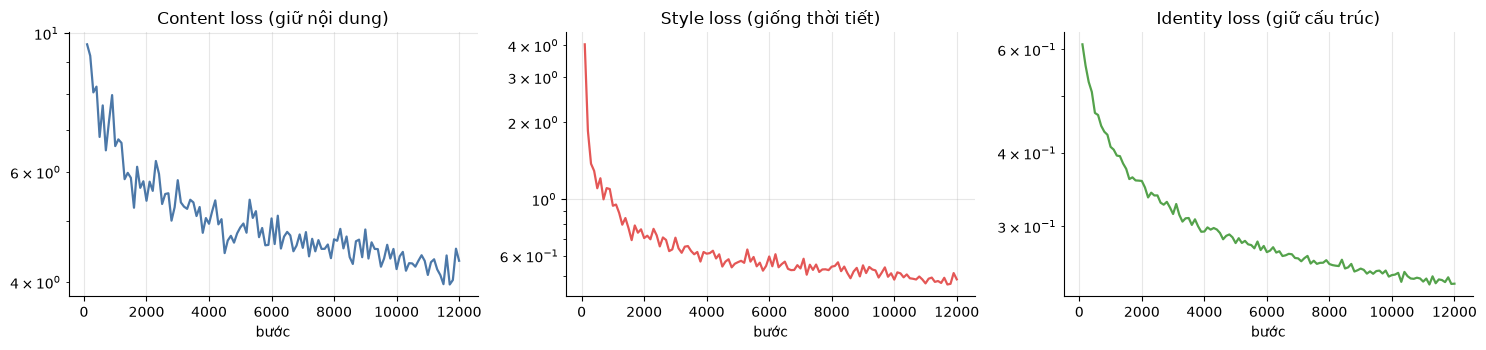

Content loss: trung bình bước 3–5k = 5.068  ->  bước 10–12k = 4.257 (chỉ giảm thêm 16% trong 7.000 bước) => đã hội tụ.


In [11]:
history = json.load(open(ROOT / "checkpoints/history.json"))
steps = [h["step"] for h in history]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, key, name, col in zip(axes,
        ["content", "style", "identity"],
        ["Content loss (giữ nội dung)", "Style loss (giống thời tiết)", "Identity loss (giữ cấu trúc)"],
        ["#4C78A8", "#E45756", "#54A24B"]):
    ax.plot(steps, [h[key] for h in history], color=col, lw=1.6)
    ax.set_title(name); ax.set_xlabel("bước"); ax.set_yscale("log"); ax.grid(alpha=.3)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

first = np.mean([h["content"] for h in history if 3000 <= h["step"] <= 5000])
last  = np.mean([h["content"] for h in history if h["step"] >= 10000])
print(f"Content loss: trung bình bước 3–5k = {first:.3f}  ->  bước 10–12k = {last:.3f} "
      f"(chỉ giảm thêm {100*(first-last)/first:.0f}% trong 7.000 bước) => đã hội tụ.")

### 3.3. Nạp mô hình đã huấn luyện đầy đủ

In [12]:
ckpt = torch.load(ROOT / "checkpoints/weather_adain.pth", map_location=DEVICE, weights_only=False)
decoder.load_state_dict(ckpt["decoder"])
decoder.eval()
print(f"Đã nạp checkpoint: {ckpt['step']:,} bước, thời gian huấn luyện {ckpt.get('minutes','?')} phút")

Đã nạp checkpoint: 12,000 bước, thời gian huấn luyện 37 phút


---
## 4. Khối ② — Guided Filter

He, Sun, Tang, *Guided Image Filtering*, ECCV 2010.

**Vấn đề.** AdaIN đổi tông màu rất tốt nhưng làm nhoè biên, ảnh trông như tranh vẽ — không dùng
để huấn luyện detector được.

**Ý tưởng.** Coi ảnh AdaIN là tín hiệu cần lọc $p$, ảnh gốc là **ảnh dẫn hướng** $I$. Trong mỗi
cửa sổ nhỏ, giả thiết đầu ra là hàm **tuyến tính** của ảnh dẫn hướng:

$$q_i = a^{\mathsf T} I_i + b, \qquad
a = (\Sigma + \varepsilon U)^{-1}\,\mathrm{cov}(I, p), \qquad
b = \bar p - a^{\mathsf T}\bar I$$

Ý nghĩa trực quan: $a$ là **hệ số tương phản cục bộ**, $b$ là **độ lệch màu cục bộ**. Vì $q$ là
hàm tuyến tính của $I$ nên $\nabla q \parallel \nabla I$ — **biên nằm đúng chỗ biên của ảnh gốc**.

**Bán kính cửa sổ quyết định chất lượng** — đây là chi tiết cài đặt quan trọng nhất của cả
pipeline, ban đầu nhóm đặt sai và ảnh ra bị mờ:

| Bán kính | $a$, $b$ biến đổi | Kết quả |
|---|---|---|
| nhỏ ($r=8$) | nhanh, bám nhiễu cục bộ | $q \approx$ ảnh AdaIN đã làm mượt → **ảnh mờ** |
| lớn ($r=32$) | chậm, mượt theo không gian | $q =$ ảnh gốc × trường tương phản/màu mượt → **ảnh sắc nét** |

Với bán kính lớn, đầu ra chính là **ảnh chụp gốc giữ nguyên 100% chi tiết**, chỉ bị nhân một
trường độ tương phản và cộng một trường lệch màu do AdaIN quyết định — đúng bằng thứ ta cần.

In [13]:
def box_filter(x, r):
    """Trung bình trên cửa sổ (2r+1)x(2r+1), giữ nguyên kích thước."""
    return F.avg_pool2d(F.pad(x, (r, r, r, r), mode="reflect"), 2 * r + 1, stride=1)


def _inv3x3_sym(a11, a12, a13, a22, a23, a33):
    """Nghịch đảo ma trận đối xứng 3x3 bằng phần phụ đại số, tính cho từng pixel."""
    c11 = a22 * a33 - a23 * a23; c12 = a13 * a23 - a12 * a33; c13 = a12 * a23 - a13 * a22
    c22 = a11 * a33 - a13 * a13; c23 = a13 * a12 - a11 * a23; c33 = a11 * a22 - a12 * a12
    inv = 1.0 / (a11 * c11 + a12 * c12 + a13 * c13 + 1e-12)
    return c11*inv, c12*inv, c13*inv, c22*inv, c23*inv, c33*inv


def guided_filter(guide, src, radius=32, eps=2e-5):
    """guide (ảnh gốc), src (ảnh AdaIN): (B,3,H,W) trong [0,1]. Ảnh dẫn hướng MÀU 3 kênh."""
    guide, src = guide.float(), src.float()
    I = [guide[:, i:i+1] for i in range(3)]
    mean_I = [box_filter(t, radius) for t in I]
    mean_p = box_filter(src, radius)

    cov_I = lambda i, j: box_filter(I[i] * I[j], radius) - mean_I[i] * mean_I[j]
    n11, n12, n13, n22, n23, n33 = _inv3x3_sym(
        cov_I(0,0)+eps, cov_I(0,1), cov_I(0,2), cov_I(1,1)+eps, cov_I(1,2), cov_I(2,2)+eps)

    out = []
    for ch in range(3):
        g = [box_filter(I[k] * src[:, ch:ch+1], radius) - mean_I[k] * mean_p[:, ch:ch+1]
             for k in range(3)]
        a0 = n11*g[0] + n12*g[1] + n13*g[2]
        a1 = n12*g[0] + n22*g[1] + n23*g[2]
        a2 = n13*g[0] + n23*g[1] + n33*g[2]
        b  = mean_p[:, ch:ch+1] - a0*mean_I[0] - a1*mean_I[1] - a2*mean_I[2]
        out.append(box_filter(a0, radius)*I[0] + box_filter(a1, radius)*I[1]
                   + box_filter(a2, radius)*I[2] + box_filter(b, radius))
    return torch.cat(out, 1).clamp(0, 1)

print("Đã định nghĩa Guided Filter (ảnh dẫn hướng màu).")

Đã định nghĩa Guided Filter (ảnh dẫn hướng màu).


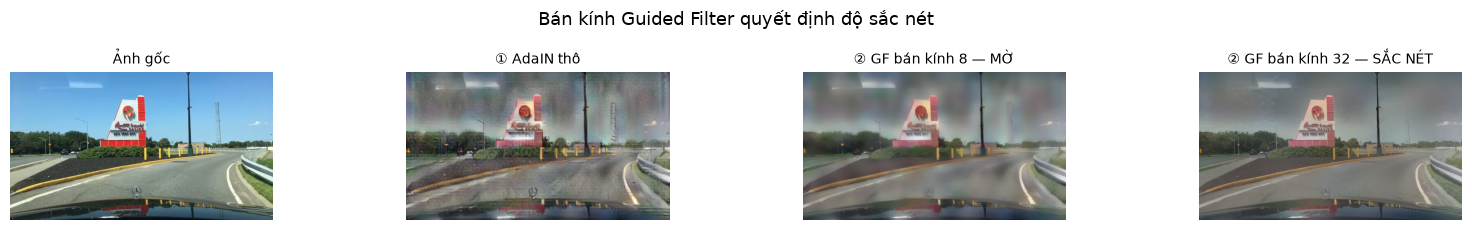

In [14]:
@torch.no_grad()
def adain_transfer(content_np, style_np, alpha=1.0, std_floor=0.4):
    """Chạy khối ① : ảnh -> AdaIN -> Decoder -> ảnh (chưa hậu xử lý)."""
    c, s = to_t(content_np), to_t(style_np)
    _, _, h, w = c.shape
    ph, pw = (-h) % 8, (-w) % 8                    # VGG hạ 3 lần độ phân giải
    cp = F.pad(c, (0, pw, 0, ph), mode="reflect") if (ph or pw) else c
    t = adain(encoder(cp), encoder(s), std_floor=std_floor)
    t = alpha * t + (1 - alpha) * encoder(cp)
    return decoder(t).clamp(0, 1)[:, :, :h, :w], c


# So sánh bán kính: đây là lỗi cấu hình mà nhóm đã gặp
content = load_img(ROOT / splits["content_val"][30])
style   = load_img(ROOT / splits["style_pool"]["rain"][5], 512)
raw, c_t = adain_transfer(content, style)

show([content, to_np(raw),
      to_np(guided_filter(c_t, raw, radius=8,  eps=2e-4)),
      to_np(guided_filter(c_t, raw, radius=32, eps=2e-5))],
     ["Ảnh gốc", "① AdaIN thô", "② GF bán kính 8 — MỜ", "② GF bán kính 32 — SẮC NÉT"],
     title="Bán kính Guided Filter quyết định độ sắc nét")

---
## 5. Khối ③ — Hiệu ứng thời tiết theo mô hình vật lý

AdaIN khớp thống kê **theo kênh** nên về bản chất **không thể** tạo ra vệt mưa hay bông tuyết —
đó là chi tiết *cục bộ*, không phải thống kê toàn cục. Khối thứ ba bù đúng điểm này.

- **Sương mù / mù khô / bão cát** — mô hình tán xạ khí quyển (Narasimhan & Nayar, IJCV 2002):
  $$I'(x) = I(x)\,t(x) + A\,\bigl(1 - t(x)\bigr), \qquad t(x) = e^{-\beta d(x)}$$
  Độ sâu $d$ xấp xỉ theo giả thiết mặt đường phẳng: điểm càng gần đường chân trời càng xa.
- **Mưa** — nhiễu thưa được làm mờ chuyển động theo một góc nghiêng để thành vệt.
- **Tuyết** — bông tuyết ở ba lớp độ sâu (xa: nhỏ và mờ; gần: to và rõ).

Tất cả đều là **phép biến đổi tại chỗ trên từng điểm ảnh** → không làm dịch chuyển vật thể.

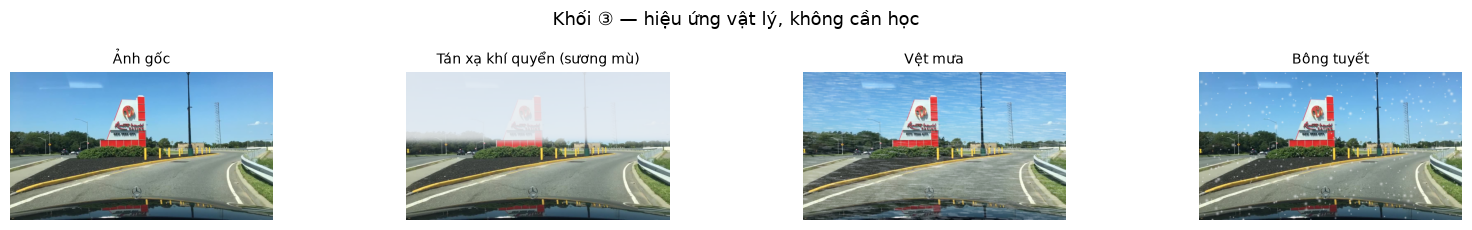

In [15]:
def depth_prior(h, w, horizon=0.45):
    """Xấp xỉ độ sâu (0 = gần, 1 = xa) theo giả thiết mặt đường phẳng."""
    y = np.arange(h, dtype=np.float32)[:, None]
    y_h = horizon * h
    d = np.empty((h, 1), np.float32)
    below = (y > y_h)[:, 0]
    d[below]  = 1.0 / (y[below] - y_h + 1e-3)
    d[~below] = d[below].max() if below.any() else 1.0
    d = np.clip(d / (d.max() + 1e-6), 0, 1)
    return cv2.GaussianBlur(np.repeat(d, w, 1), (0, 0), sigmaX=max(w, h) * 0.01)


def add_fog(img, beta=1.8, airlight=(235, 238, 242)):
    """I' = I·t + A·(1-t),  t = exp(-beta·d)  — mô hình tán xạ khí quyển."""
    d = depth_prior(*img.shape[:2])[..., None]
    t = np.exp(-beta * d)
    A = np.array(airlight, np.float32).reshape(1, 1, 3)
    return np.clip(img.astype(np.float32) * t + A * (1 - t), 0, 255).astype(np.uint8)


def rain_layer(h, w, intensity=0.5, angle=-12.0, length=22, rng=None):
    """Mặt nạ vệt mưa: nhiễu thưa + làm mờ chuyển động theo góc nghiêng."""
    rng = rng or np.random.default_rng()
    noise = (rng.random((h, w), dtype=np.float32) < 0.004 + 0.020 * intensity).astype(np.float32)
    noise *= rng.uniform(0.5, 1.0, (h, w)).astype(np.float32)
    L = max(3, int(length * (0.6 + 0.8 * intensity)))
    k = np.zeros((L, L), np.float32); k[L // 2, :] = 1.0
    k = cv2.warpAffine(k, cv2.getRotationMatrix2D((L/2-.5, L/2-.5), angle, 1.0), (L, L))
    streaks = cv2.GaussianBlur(cv2.filter2D(noise, -1, k / (k.sum() + 1e-8)), (3, 3), 0)
    return streaks / (streaks.max() + 1e-6)


def snow_layer(h, w, intensity=0.5, rng=None):
    """Mặt nạ bông tuyết ở 3 lớp độ sâu."""
    rng = rng or np.random.default_rng()
    flakes = np.zeros((h, w), np.float32)
    for radius, share, blur in ((1, .55, .6), (2, .30, 1.0), (3, .15, 1.8)):
        n = int(h * w * (0.00035 + 0.0022 * intensity) * share)
        layer = np.zeros((h, w), np.float32)
        for x, y in zip(rng.integers(0, w, n), rng.integers(0, h, n)):
            cv2.circle(layer, (int(x), int(y)), radius, float(rng.uniform(.6, 1.)), -1)
        flakes = np.maximum(flakes, cv2.GaussianBlur(layer, (0, 0), sigmaX=blur))
    return flakes


def overlay_particles(img, kind, strength=0.5, seed=None):
    """Chỉ phủ HẠT — AdaIN đã lo tông màu và độ mù rồi."""
    if strength <= 0: return img
    rng = np.random.default_rng(seed); h, w = img.shape[:2]
    if kind == "rain":
        mask, tint = rain_layer(h, w, strength, float(rng.uniform(-22, 8)), rng=rng), np.array([200., 206., 216.])
    elif kind == "snow":
        mask, tint = snow_layer(h, w, strength, rng), np.array([252., 252., 255.])
    elif kind in ("sand", "haze"):
        grain = cv2.GaussianBlur(rng.normal(0, 3 + (12. if kind == "sand" else 5.) * strength,
                                            (h, w, 1)).astype(np.float32), (0, 0), 1.2)[..., None]
        return np.clip(img.astype(np.float32) + grain, 0, 255).astype(np.uint8)
    else:
        return img                                   # sương mù: không có hạt rời
    veil = mask[..., None] * tint * (0.5 + 0.5 * strength)
    return np.clip(255. - (255. - img.astype(np.float32)) * (255. - veil) / 255., 0, 255).astype(np.uint8)


show([content, add_fog(content, beta=2.2),
      overlay_particles(content, "rain", 0.6, seed=0),
      overlay_particles(content, "snow", 0.6, seed=0)],
     ["Ảnh gốc", "Tán xạ khí quyển (sương mù)", "Vệt mưa", "Bông tuyết"],
     title="Khối ③ — hiệu ứng vật lý, không cần học")

---
## 6. Ghép 3 khối thành pipeline hoàn chỉnh

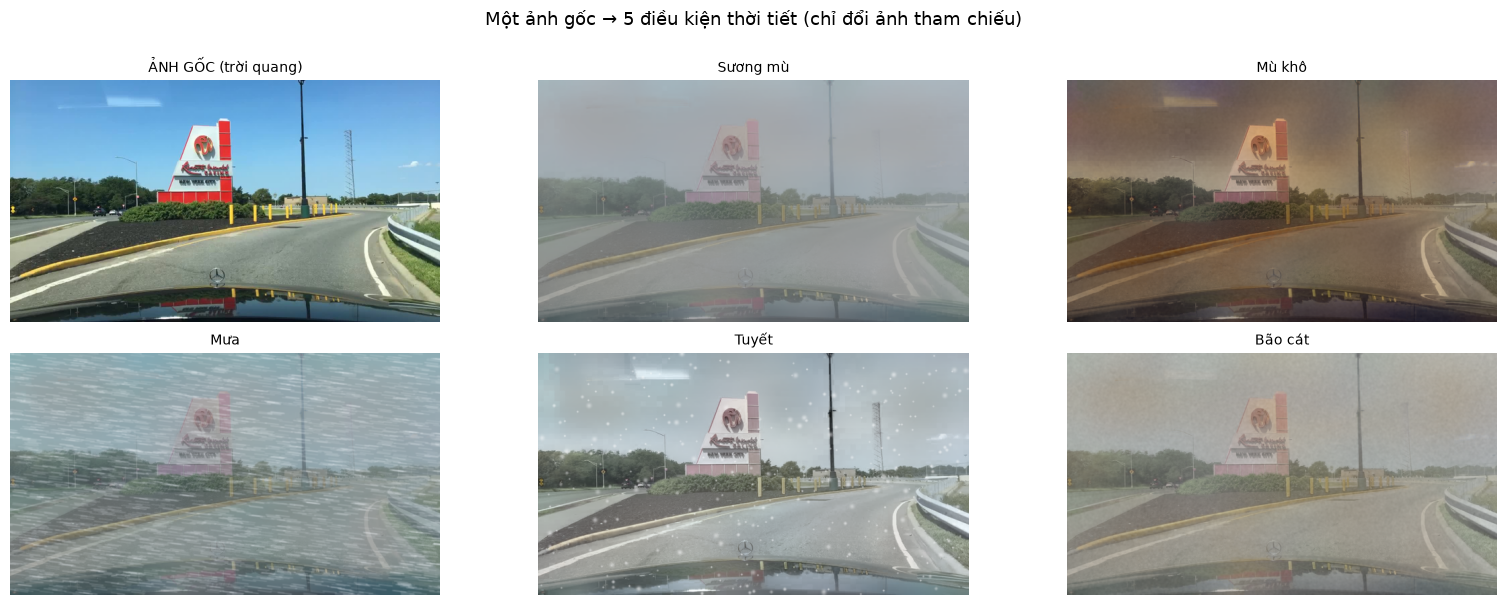

In [16]:
@torch.no_grad()
def augment(content_np, style_np, weather="fog", alpha=1.0,
            particles=0.45, refine=True, std_floor=0.4, seed=0):
    """① AdaIN  ->  ② Guided Filter  ->  ③ Phủ hạt."""
    out, c_t = adain_transfer(content_np, style_np, alpha=alpha, std_floor=std_floor)
    if refine:
        out = guided_filter(c_t, out, radius=32, eps=2e-5)     # ②
    res = to_np(out)
    if particles > 0:
        res = overlay_particles(res, weather, particles, seed=seed)   # ③
    return res


WEATHER_VI = {"fog": "Sương mù", "haze": "Mù khô", "rain": "Mưa",
              "snow": "Tuyết", "sand": "Bão cát"}
rng = random.Random(2)
content = load_img(ROOT / splits["content_val"][30])

imgs, titles = [content], ["ẢNH GỐC (trời quang)"]
for k in WEATHER_VI:
    st = load_img(ROOT / rng.choice(splits["style_pool"][k]), 512)
    imgs.append(augment(content, st, weather=k, seed=1)); titles.append(WEATHER_VI[k])
show(imgs, titles, cols=3, title="Một ảnh gốc → 5 điều kiện thời tiết (chỉ đổi ảnh tham chiếu)")

### 6.1. Điều khiển cường độ bằng `alpha`

$t = \alpha\cdot\mathrm{AdaIN}(c,s) + (1-\alpha)\cdot c$ — nhờ đó **một cặp ảnh sinh ra được
nhiều mức thời tiết nặng/nhẹ khác nhau**, rất hữu ích để đa dạng hoá dữ liệu.

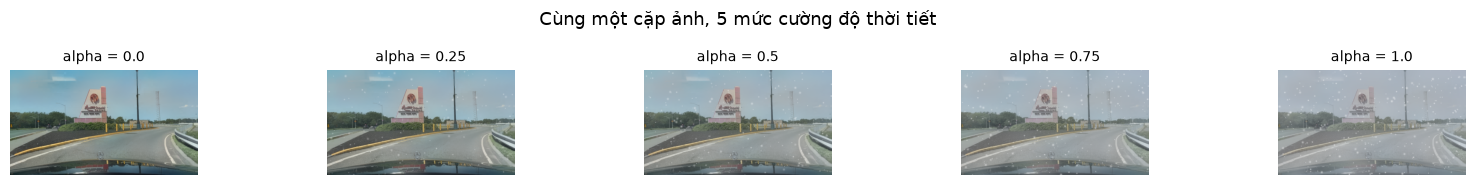

In [17]:
style = load_img(ROOT / splits["style_pool"]["snow"][3], 512)
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
show([augment(content, style, "snow", alpha=a, particles=0.45 * a, seed=1) for a in alphas],
     [f"alpha = {a}" for a in alphas], title="Cùng một cặp ảnh, 5 mức cường độ thời tiết")

---
## 7. Bằng chứng: nhãn bounding box vẫn khớp

Vẽ **cùng một bộ bounding box** của ảnh gốc lên cả hai ảnh. Nếu các khung vẫn ôm khít vật thể
thì mỗi ảnh sinh ra chỉ cần **sao chép file nhãn** của ảnh gốc — chi phí gán nhãn bằng **0**.

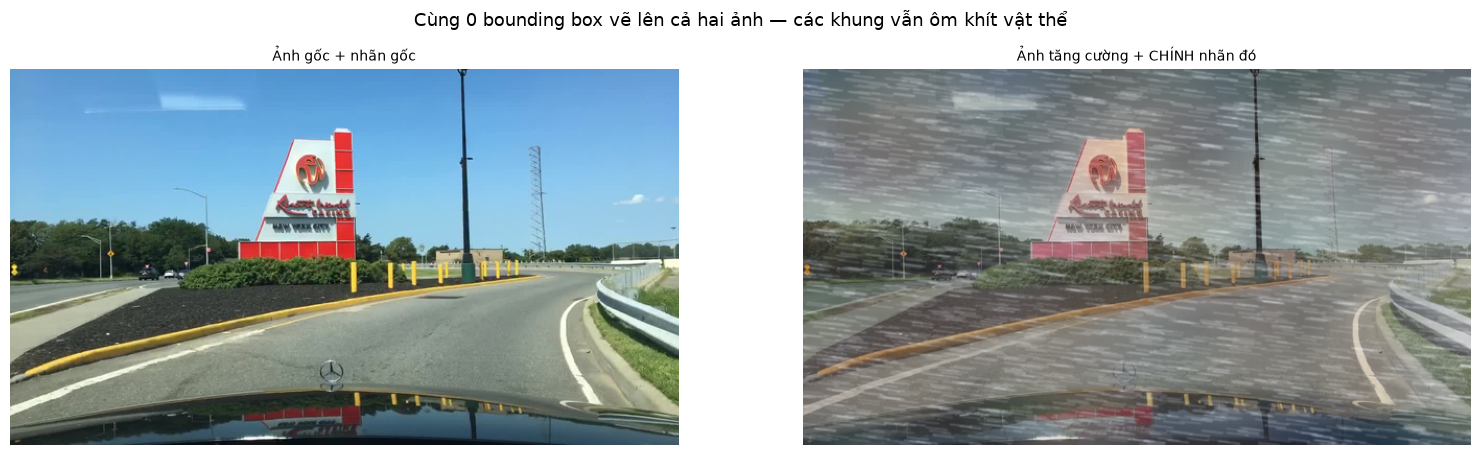

In [18]:
def draw_boxes(img, boxes, classes):
    palette = [(230,60,60), (60,160,230), (70,200,120), (245,170,40), (180,100,230),
               (240,120,180), (100,220,220), (200,200,90), (150,150,250), (250,150,100)]
    im = img.copy(); H, W = img.shape[:2]
    for cid, xc, yc, bw, bh in boxes:
        x0, y0 = int((xc - bw/2) * W), int((yc - bh/2) * H)
        x1, y1 = int((xc + bw/2) * W), int((yc + bh/2) * H)
        col = palette[cid % len(palette)]
        cv2.rectangle(im, (x0, y0), (x1, y1), col, 2)
        cv2.putText(im, classes[cid], (x0 + 2, max(12, y0 - 4)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, col, 1, cv2.LINE_AA)
    return im


rel = splits["content_val"][30]
boxes = [(int(p[0]), *map(float, p[1:])) for p in
         (l.split() for l in (ROOT / "data/processed/labels" / f"{Path(rel).stem}.txt").read_text().split("\n"))
         if len(p) == 5]
boxes = [b for b in boxes if b[3] * b[4] > 0.002][:12]

st  = load_img(ROOT / splits["style_pool"]["rain"][5], 512)
aug_img = augment(content, st, "rain", seed=1)
show([draw_boxes(content, boxes, splits["classes"]),
      draw_boxes(aug_img, boxes, splits["classes"])],
     ["Ảnh gốc + nhãn gốc", "Ảnh tăng cường + CHÍNH nhãn đó"],
     title=f"Cùng {len(boxes)} bounding box vẽ lên cả hai ảnh — các khung vẫn ôm khít vật thể")

---
## 8. Đánh giá định lượng chất lượng ảnh

Chạy bằng `python evaluate.py --n 150`. Hai nhóm chỉ số trả lời hai câu hỏi:

1. **Ảnh sinh ra có giữ được nội dung không?** (nhãn cũ còn dùng được không) — SSIM, PSNR,
   **EdgeRecall** = tỉ lệ biên Canny của ảnh gốc còn tìm thấy trong ảnh sinh ra. Dùng *recall*
   chứ không dùng *IoU* vì việc có thêm biên mới (vệt mưa) là điều mong muốn, không phải lỗi.
2. **Ảnh sinh ra có giống thời tiết xấu thật không?** — **FID** so với ảnh mưa/tuyết thật của
   BDD100K. Vì tập thật chỉ có mưa và tuyết nên phần đo FID cũng chỉ sinh mưa/tuyết cho khớp loại.

In [19]:
m = json.load(open(ROOT / "outputs/eval/metrics.json"))
r = m["results"]
rows = [("Không tăng cường (mốc tham chiếu)", "_no_augment"),
        ("Baseline vật lý (không học)",       "physics"),
        ("Chỉ AdaIN",                          "adain"),
        ("AdaIN + Guided Filter + hạt (đề xuất)", "ours")]

print(f"Đánh giá trên {m['n_content']} ảnh · loại thời tiết đem so: {', '.join(m.get('weathers', []))}\n")
print(f"{'Phương pháp':<40}{'SSIM↑':>9}{'PSNR↑':>9}{'EdgeRec↑':>11}{'FID↓':>10}")
print("-" * 79)
for name, key in rows:
    v = r[key]
    f = lambda x, p=4: "—" if not isinstance(x, (int, float)) or x != x or abs(x) == float("inf") else f"{x:.{p}f}"
    print(f"{name:<40}{f(v['ssim']):>9}{f(v['psnr'],2):>9}{f(v['edge_recall']):>11}{v['fid']:>10.2f}")

Đánh giá trên 150 ảnh · loại thời tiết đem so: rain, snow

Phương pháp                                 SSIM↑    PSNR↑   EdgeRec↑      FID↓
-------------------------------------------------------------------------------
Không tăng cường (mốc tham chiếu)          1.0000        —     1.0000     99.40
Baseline vật lý (không học)                0.6076    13.32     0.5092    177.03
Chỉ AdaIN                                  0.4521    14.13     0.6073    125.85
AdaIN + Guided Filter + hạt (đề xuất)      0.6100    14.61     0.4997    164.38


**Đọc kết quả một cách trung thực.** Không phương pháp nào thắng tuyệt đối:

- Phương pháp **đề xuất** giữ nội dung tốt nhất (SSIM, PSNR cao nhất) nhờ Guided Filter bán kính lớn.
- **AdaIN thuần** lại thắng FID và EdgeRecall. Lý do ở khối phủ hạt: vệt mưa và bông tuyết làm
  ảnh trông "ra thời tiết" với mắt người, nhưng chúng là dấu vết tổng hợp bị mạng Inception phạt
  nặng, đồng thời che bớt biên. Đáng chú ý là ảnh mưa thật trong BDD100K chụp qua kính chắn gió
  nên gần như **không thấy vệt mưa rời**. → Với dữ liệu dashcam nên **giảm mật độ hạt**.
- FID cũng có giới hạn: ảnh gốc chưa tăng cường tuy khác hẳn về thời tiết nhưng là **ảnh chụp
  thật 100%**, cùng camera và bố cục với tập test, nên luôn có lợi thế FID tự nhiên. Bằng chứng
  thật sự về giá trị nằm ở thí nghiệm dưới đây.

---
## 9. Thí nghiệm kiểm chứng — dữ liệu sinh ra có thực sự hữu ích?

Đây là thí nghiệm quan trọng nhất. Chạy bằng:

```bash
python augment_dataset.py --k 1 --limit 1000
python experiments/detector_experiment.py --epochs 20 --n-train 1000 --long-baseline
```

Ba mô hình **YOLOv8n giống hệt nhau** về kiến trúc, siêu tham số và seed, chỉ khác tập huấn luyện:

| | Tập huấn luyện | Số epoch |
|---|---|---|
| **A. Baseline** | 1.000 ảnh trời quang | 20 |
| **B. Baseline-long** | *cùng* 1.000 ảnh đó | 40 |
| **C. Augmented** | 1.000 ảnh trời quang + 1.000 ảnh do mô hình sinh ra | 20 |

**Vì sao cần nhánh B?** Nhánh C có gấp đôi số ảnh nên với cùng số epoch nó cũng nhận **gấp đôi
số bước cập nhật gradient**. Nếu chỉ so C với A thì không phân biệt được phần cải thiện đến từ
*dữ liệu mới* hay chỉ từ *huấn luyện lâu hơn*. Nhánh B có đúng số bước cập nhật như C nhưng
**không có dữ liệu mới** → phép so sánh công bằng là **C − B**.

Các phép tăng cường màu sẵn có của YOLO (HSV, mosaic, erasing) được **tắt** để cô lập ảnh hưởng
của dữ liệu do mô hình sinh ra.

In [20]:
det = json.load(open(ROOT / "experiments/detector/results.json"))
mm  = det["models"]
cols = [c for c in ("baseline", "baseline_long", "augmented") if c in mm]
vi   = {"baseline": "A.Baseline", "baseline_long": "B.Base-long", "augmented": "C.Augmented"}
ref_key = "baseline_long" if "baseline_long" in mm else "baseline"

print(f"Tập test: {det['counts']['test_adverse']} ảnh mưa/tuyết THẬT · "
      f"đối chứng {det['counts']['test_clear']} ảnh trời quang\n")
print(f"{'Tập kiểm tra':<32}" + "".join(f"{vi[c]:>15}" for c in cols) + f"{'C − B':>18}")
print("-" * (32 + 15 * len(cols) + 18))
for tag, name in (("test_adverse", "Thời tiết xấu THẬT"), ("test_clear", "Trời quang (đối chứng)")):
    for k in ("mAP50", "mAP50-95"):
        ref = mm[ref_key][tag][k]; d = mm["augmented"][tag][k] - ref
        print(f"{name + ' · ' + k:<32}" + "".join(f"{mm[c][tag][k]:>15.4f}" for c in cols)
              + f"{d:>+11.4f} ({d/max(ref,1e-9)*100:+.1f}%)")

Tập test: 375 ảnh mưa/tuyết THẬT · đối chứng 240 ảnh trời quang

Tập kiểm tra                         A.Baseline    B.Base-long    C.Augmented             C − B
-----------------------------------------------------------------------------------------------
Thời tiết xấu THẬT · mAP50               0.2363         0.2451         0.2603    +0.0153 (+6.2%)
Thời tiết xấu THẬT · mAP50-95            0.1299         0.1339         0.1411    +0.0072 (+5.3%)
Trời quang (đối chứng) · mAP50           0.3028         0.3204         0.3349    +0.0145 (+4.5%)
Trời quang (đối chứng) · mAP50-95         0.1727         0.1797         0.1877    +0.0080 (+4.5%)


### Kết luận của thí nghiệm

✅ Thêm **1.000 ảnh sinh tự động** — tốn **0 giây gán nhãn** — giúp mAP50 trên ảnh thời tiết xấu
**thật** tăng **+6,2%** so với nhánh đối chứng có **cùng số bước cập nhật gradient**.

Quan trọng hơn: mức tăng ở **thời tiết xấu (+6,2%)** *cao hơn* ở **trời quang (+4,5%)** — chứng
tỏ dữ liệu tăng cường có tác dụng **riêng** cho khả năng chịu thời tiết, chứ không đơn thuần là
"có thêm dữ liệu thì mô hình nào cũng tốt hơn". Hàng "trời quang" đồng thời xác nhận việc tăng
cường **không làm mô hình kém đi** trong điều kiện bình thường — một rủi ro thường gặp khi tăng
cường quá tay.

---
## 10. Kết luận

**Đã làm được**

1. Xây dựng trọn vẹn pipeline sinh ảnh giao thông thời tiết xấu từ **2 ảnh đầu vào**, đúng yêu
   cầu đề bài, hoàn toàn bằng **mã nguồn mở**.
2. Chỉ **3,51 triệu tham số** cần huấn luyện (decoder); VGG-19 và YOLOv8n đều dùng trọng số
   pretrain. Huấn luyện xong trong **37 phút** trên một GPU tiêu dùng.
3. **Nhãn bounding box tái sử dụng 100%** — chi phí gán nhãn cho dữ liệu mới bằng 0.
4. Kiểm chứng bằng **thí nghiệm downstream thật**: mAP50 trên ảnh thời tiết xấu thật tăng
   **+6,2%** so với nhánh đối chứng cùng số bước cập nhật.
5. Bàn giao kèm **web demo Gradio**, chạy toàn bộ quy trình bằng **một lệnh** (`bash run_all.sh`).

**Hạn chế**

1. AdaIN chuyển thống kê **toàn cục**, chưa phân biệt vùng trời với mặt đường — sương mù có độ
   dày như nhau ở gần và ở xa.
2. Không có bản đồ độ sâu thật; module vật lý dùng giả thiết mặt đường phẳng.
3. Khối phủ hạt làm giảm FID và EdgeRecall trên dữ liệu dashcam (xem mục 8).
4. DAWN chỉ được phép dùng cho mục đích nghiên cứu.

**Hướng phát triển**

1. Thêm mặt nạ phân vùng trời / đường để chuyển tông riêng cho từng vùng.
2. Dùng mô hình ước lượng độ sâu đơn ảnh (Depth Anything, MiDaS) thay giả thiết mặt đường phẳng.
3. Thay AdaIN bằng AdaAttN hoặc WCT² để bám cấu trúc tốt hơn.
4. Thu thập ảnh tham chiếu thời tiết **tại Việt Nam** để khớp bối cảnh triển khai.
5. Mở rộng sang ban đêm, chói nắng ngược, đèn pha ngược chiều.

---

## Tài liệu tham khảo

1. X. Huang, S. Belongie. *Arbitrary Style Transfer in Real-time with Adaptive Instance Normalization.* ICCV 2017.
2. K. He, J. Sun, X. Tang. *Guided Image Filtering.* ECCV 2010.
3. F. Yu et al. *BDD100K: A Diverse Driving Dataset for Heterogeneous Multitask Learning.* CVPR 2020.
4. M. A. Kenk, M. Hassaballah. *DAWN: Vehicle Detection in Adverse Weather Nature Dataset.* 2020.
5. S. G. Narasimhan, S. K. Nayar. *Vision and the Atmosphere.* IJCV 2002.
6. Y. Li et al. *A Closed-form Solution to Photorealistic Image Stylization.* ECCV 2018 (PhotoWCT).